# Midterm Project Analysis: Missile Attacks on Ukraine

This notebook contains the analysis of Russian missile and drone strikes against Ukrainian infrastructure.

## Environment Setup

In [61]:
# Import required packages
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('All packages imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

All packages imported successfully!
Pandas version: 3.0.1
NumPy version: 2.4.2


## Load Dataset

Data sources:
- [Massive Missile Attacks on Ukraine / Data Review](https://www.kaggle.com/code/piterfm/massive-missile-attacks-on-ukraine-data-review)
- [Massive Missile Attacks on Ukraine](https://www.kaggle.com/datasets/piterfm/massive-missile-attacks-on-ukraine?select=missile_attacks_daily.csv)
- [Open-Meteo Weather API](https://open-meteo.com/en/docs?latitude=50.4547&longitude=30.5238&time_mode=time_interval&start_date=2026-03-07&end_date=2026-03-21&hourly=cloud_cover)

In [62]:
# Load the datasets
attacks_df = pd.read_csv('data/missile_attacks_daily.csv')
weapons_df = pd.read_csv('data/missiles_and_uavs.csv')

print(f'Missile Attacks Daily - Shape: {attacks_df.shape}')
print(f'Missiles and UAVs - Shape: {weapons_df.shape}')
print(f'\nFirst 10 rows of missile_attacks_daily.csv:')
attacks_df.head(10)

Missile Attacks Daily - Shape: (3412, 22)
Missiles and UAVs - Shape: (64, 12)

First 10 rows of missile_attacks_daily.csv:


,time_start,time_end,model,launch_place,target,target_main,launched,destroyed,not_reach_goal,still_attacking,...,num_hit_location,num_fall_fragment_location,carrier,turbojet,turbojet_destroyed,affected region,destroyed_details,launched_details,launch_place_details,source
0,2026-02-15 18:00,2026-02-16 09:00,X-31P,Zaporizhzhia oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
1,2026-02-15 18:00,2026-02-16 09:00,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,62.0,52.0,0.0,1.0,...,8.0,2.0,NaN,NaN,NaN,NaN,"{'south': 1, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
2,2026-02-15 18:00,2026-02-16 09:00,Iskander-M,Bryansk oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
3,2026-02-15 18:00,2026-02-16 09:00,3M22 Zircon,Crimea,Ukraine,NaN,4.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02FADHWssAwVCGqvfhSJy6p33grx...
4,2026-02-14 18:30,2026-02-15 08:00,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Brya...",Ukraine,NaN,83.0,55.0,0.0,3.0,...,12.0,3.0,NaN,NaN,NaN,NaN,"{'south': 22, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid0GzUWTJ83g643MFnrtmZdGxn6tVf...
5,2026-02-15,2026-02-15,Молнія,NaN,south,NaN,3.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02AfkGxkTncqCgzPjcwqNkZRY...
6,2026-02-15,2026-02-15,Reconnaissance UAV,NaN,south,NaN,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02AfkGxkTncqCgzPjcwqNkZRY...
7,2026-02-13 18:30,2026-02-14 08:30,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,112.0,91.0,0.0,3.0,...,11.0,2.0,NaN,NaN,NaN,NaN,"{'south': 6, 'west': 11, 'east': NaN, 'north':...",NaN,NaN,kpszsu/posts/pfbid02c1AgHwW6Jw4opmxgGEA1bP8WHy...
8,2026-02-13 18:30,2026-02-14 08:30,Iskander-M,Kursk oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid02c1AgHwW6Jw4opmxgGEA1bP8WHy...
9,2026-02-14,2026-02-14,Молнія,NaN,south,NaN,20.0,20.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02z6RNnsh7nLkD38sPEkKnoAc...


In [63]:
print(f'\nFirst 10 rows of missiles_and_uavs.csv:')
weapons_df.head(10)


First 10 rows of missiles_and_uavs.csv:


,model,category,national_origin,type,launch_platform,name,name_NATO,in_sevice,designer,manufacturer,guidance_system,unit_cost
0,Eleron,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,ENICS,NaN,NaN
1,Forpost,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Ural Works of Civil Aviation,NaN,NaN
2,Granat-4,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Ижмаш – беспилотные системы,NaN,NaN
3,Kub,UAV,russia,loitering munition,NaN,NaN,NaN,NaN,NaN,ZALA Aero Group,NaN,NaN
4,Lancet,UAV,russia,loitering munition,NaN,NaN,NaN,NaN,NaN,ZALA Aero Group,NaN,NaN
5,Merlin-VR,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Mohajer-6,UAV,iran,multirole ISTAR,NaN,NaN,NaN,NaN,NaN,Qods Aviation Industry Company,NaN,NaN
7,Orion,UAV,russia,reconnaissance and armed,NaN,NaN,NaN,NaN,NaN,Kronstadt Group,NaN,NaN
8,Orlan-10,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Special Technology Center,NaN,NaN
9,Orlan-10 and Orlan-30 and ZALA and Supercam,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exploratory Data Analysis

In [64]:
# Dataset overview
print('Missile Attacks Daily Dataset Information:')
print('='*50)
print(attacks_df.info())
print('\nBasic Statistics:')
print(attacks_df.describe())

Missile Attacks Daily Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 3412 entries, 0 to 3411
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time_start                  3412 non-null   str    
 1   time_end                    3412 non-null   str    
 2   model                       3412 non-null   str    
 3   launch_place                1758 non-null   str    
 4   target                      3382 non-null   str    
 5   target_main                 52 non-null     str    
 6   launched                    3409 non-null   float64
 7   destroyed                   3406 non-null   float64
 8   not_reach_goal              575 non-null    float64
 9   still_attacking             96 non-null     float64
 10  border_crossing             3412 non-null   str    
 11  is_shahed                   161 non-null    float64
 12  num_hit_location            270 non-null    float64
 13  n

In [65]:
# Weapons dataset overview
print('Missiles and UAVs Dataset Information:')
print('='*50)
print(weapons_df.info())
print('\nBasic Statistics:')
print(weapons_df.describe())

# Missing values analysis
print('\n\nMissing Values - Missile Attacks Daily:')
print(attacks_df.isnull().sum())
print('\nMissing Values - Missiles and UAVs:')
print(weapons_df.isnull().sum())

Missiles and UAVs Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            64 non-null     str    
 1   category         64 non-null     str    
 2   national_origin  61 non-null     str    
 3   type             36 non-null     str    
 4   launch_platform  17 non-null     str    
 5   name             20 non-null     str    
 6   name_NATO        15 non-null     str    
 7   in_sevice        9 non-null      float64
 8   designer         4 non-null      str    
 9   manufacturer     23 non-null     str    
 10  guidance_system  2 non-null      str    
 11  unit_cost        1 non-null      str    
dtypes: float64(1), str(11)
memory usage: 6.1 KB
None

Basic Statistics:
         in_sevice
count     9.000000
mean   2008.222222
std      17.746674
min    1978.000000
25%    2006.000000
50%    2017.000000
75%    2021.000000


## Binomial Logistic Regression (GLM): Likelihood of Interception

In this section we fit a **Binomial Logistic Regression** (a Generalized Linear Model with a logit link and binomial family) to estimate the probability that a given missile or UAV is **intercepted (shot down)** by Ukrainian air defenses.

### Approach

| Step | Description |
|------|-------------|
| **1. Data Preparation** | Merge `missile_attacks_daily` with `missiles_and_uavs` on the `model` column to enrich each attack record with weapon metadata (category, type, guidance system, etc.). |
| **2. Timestamp Filtering** | Retain only rows whose `time_start` includes an explicit HH:MM timestamp; rows with date-only values are excluded because we cannot determine day-vs-night. |
| **3. Sunrise / Sunset Retrieval** | For every unique attack date we query the free **Sunrise-Sunset API** (`https://api.sunrise-sunset.org`) using Kyiv coordinates (50.45 °N, 30.52 °E) to obtain civil sunrise and sunset times. |
| **4. Day / Night Classification** | Each attack is labelled **"day"** if its `time_start` falls between sunrise and sunset, or **"night"** otherwise. |
| **5. Feature Engineering** | Construct the design matrix with categorical predictors (`model`, `category`, `type`, day/night indicator) and the response as the number of `destroyed` out of `launched` (binomial trials). |
| **6. Model Fitting** | Fit the GLM using `statsmodels` with a logit link. Evaluate coefficients, p-values, and confidence intervals to identify which features significantly predict interception probability. |
| **7. Model Evaluation** | Assess goodness-of-fit via deviance, AIC, and a confusion-matrix on predicted vs. observed interception rates. |

> **Interpretation:** A positive coefficient means the feature *increases* the log-odds of interception; a negative coefficient means it *decreases* those odds. The day/night indicator tells us whether attacks launched during daylight are more or less likely to be intercepted than nighttime attacks.

In [66]:
%pip install statsmodels requests scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [67]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import requests
from datetime import datetime, timezone
import time as _time
import warnings
import sklearn
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Step 1 – Merge datasets on 'model'
# -------------------------------------------------------------------
merged_df = attacks_df.merge(weapons_df, on='model', how='left')
print(f'Merged dataset shape: {merged_df.shape}')
print(f'Rows with weapon metadata: {merged_df["category"].notna().sum()} / {len(merged_df)}')

# -------------------------------------------------------------------
# Step 2 – Filter to rows with explicit timestamps (contain ":")
# -------------------------------------------------------------------
has_time_start = merged_df['time_start'].astype(str).str.contains(r'\d{2}:\d{2}', na=False)
has_time_end   = merged_df['time_end'].astype(str).str.contains(r'\d{2}:\d{2}', na=False)
timed_df = merged_df[has_time_start & has_time_end].copy()
print(f'\nRows with valid start AND end timestamps: {len(timed_df)} / {len(merged_df)}')

# Parse datetime columns
timed_df['time_start_dt'] = pd.to_datetime(timed_df['time_start'], errors='coerce')
timed_df['time_end_dt']   = pd.to_datetime(timed_df['time_end'],   errors='coerce')
timed_df = timed_df.dropna(subset=['time_start_dt', 'time_end_dt'])

# Extract the date of the attack start for sunrise/sunset lookup
timed_df['attack_date'] = timed_df['time_start_dt'].dt.date
print(f'Unique attack dates: {timed_df["attack_date"].nunique()}')
timed_df.head()

Merged dataset shape: (3412, 33)
Rows with weapon metadata: 3403 / 3412

Rows with valid start AND end timestamps: 1330 / 3412
Unique attack dates: 677


,time_start,time_end,model,launch_place,target,target_main,launched,destroyed,not_reach_goal,still_attacking,...,name,name_NATO,in_sevice,designer,manufacturer,guidance_system,unit_cost,time_start_dt,time_end_dt,attack_date
0,2026-02-15 18:00,2026-02-16 09:00,X-31P,Zaporizhzhia oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,Kh-31P,AS-17 'Krypton',NaN,NaN,NaN,NaN,NaN,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
1,2026-02-15 18:00,2026-02-16 09:00,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,62.0,52.0,0.0,1.0,...,NaN,NaN,NaN,NaN,Shahed Aviation Industries,NaN,NaN,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
2,2026-02-15 18:00,2026-02-16 09:00,Iskander-M,Bryansk oblast,Ukraine,NaN,1.0,0.0,NaN,NaN,...,Iskander-M,NaN,2006.0,NaN,Votkinsk Plant State Production Association,"Inertial, optical DSMAC",NaN,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
3,2026-02-15 18:00,2026-02-16 09:00,3M22 Zircon,Crimea,Ukraine,NaN,4.0,2.0,NaN,NaN,...,Zircon,SS-N-33,2021.0,NaN,NPO Mashinostroyeniya,NaN,~10 million USD,2026-02-15 18:00:00,2026-02-16 09:00:00,2026-02-15
4,2026-02-14 18:30,2026-02-15 08:00,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Brya...",Ukraine,NaN,83.0,55.0,0.0,3.0,...,NaN,NaN,NaN,NaN,Shahed Aviation Industries,NaN,NaN,2026-02-14 18:30:00,2026-02-15 08:00:00,2026-02-14


In [68]:
# -------------------------------------------------------------------
# Step 3 – Retrieve sunrise / sunset times via API (with JSON cache)
# -------------------------------------------------------------------
# Using https://api.sunrise-sunset.org (free, no key required)
# Kyiv coordinates: 50.4501 N, 30.5234 E
# Results are cached in data/sun_cache.json to avoid repeated API calls.

import json
from pathlib import Path

KYIV_LAT, KYIV_LNG = 50.4501, 30.5234
SUN_CACHE_PATH = Path('data/sun_cache.json')

unique_dates = sorted(timed_df['attack_date'].unique())

# ------ load existing cache from disk (if available) ------
if SUN_CACHE_PATH.exists():
    with open(SUN_CACHE_PATH, 'r') as f:
        raw_cache = json.load(f)
    # Convert stored strings back to pandas Timestamps
    sun_cache = {
        pd.Timestamp(k).date(): {
            'sunrise': pd.to_datetime(v['sunrise']),
            'sunset':  pd.to_datetime(v['sunset']),
        }
        for k, v in raw_cache.items()
    }
    print(f'Loaded {len(sun_cache)} cached sunrise/sunset entries from {SUN_CACHE_PATH}')
else:
    sun_cache = {}
    print('No cache file found – will fetch from API.')

# ------ fetch only the dates not already cached ------
dates_to_fetch = [d for d in unique_dates if d not in sun_cache]
print(f'Dates needed: {len(unique_dates)} | Already cached: {len(unique_dates) - len(dates_to_fetch)} | To fetch: {len(dates_to_fetch)}')

for i, d in enumerate(dates_to_fetch):
    date_str = str(d)
    url = (
        f'https://api.sunrise-sunset.org/json'
        f'?lat={KYIV_LAT}&lng={KYIV_LNG}'
        f'&date={date_str}&formatted=0'
    )
    try:
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data['status'] == 'OK':
            sunrise_utc = pd.to_datetime(data['results']['sunrise'])
            sunset_utc  = pd.to_datetime(data['results']['sunset'])
            # Convert from UTC to Kyiv local time (UTC+2 in winter / UTC+3 in summer)
            # Ukraine observes EET (UTC+2) / EEST (UTC+3).  A simple offset approach:
            # Since the data timestamps appear to already be in local (Kyiv) time,
            # we convert sunrise/sunset to UTC+2 for comparison.
            kyiv_offset = pd.Timedelta(hours=2)
            sun_cache[d] = {
                'sunrise': sunrise_utc + kyiv_offset,
                'sunset':  sunset_utc  + kyiv_offset,
            }
        else:
            print(f'  Warning: API returned status={data["status"]} for {date_str}')
    except Exception as e:
        print(f'  Error fetching {date_str}: {e}')
    # Respect API rate limits
    if (i + 1) % 5 == 0:
        _time.sleep(1)

# ------ persist cache to disk ------
if dates_to_fetch:
    serializable = {
        str(k): {
            'sunrise': v['sunrise'].isoformat(),
            'sunset':  v['sunset'].isoformat(),
        }
        for k, v in sun_cache.items()
    }
    with open(SUN_CACHE_PATH, 'w') as f:
        json.dump(serializable, f, indent=2)
    print(f'Cache updated – wrote {len(serializable)} entries to {SUN_CACHE_PATH}')

print(f'Successfully have sun data for {len(sun_cache)} / {len(unique_dates)} dates')

# Show a few examples
sample_dates = list(sun_cache.items())[:5]
for d, times in sample_dates:
    print(f'  {d}  sunrise={times["sunrise"].strftime("%H:%M")}  sunset={times["sunset"].strftime("%H:%M")}')

Loaded 677 cached sunrise/sunset entries from data/sun_cache.json
Dates needed: 677 | Already cached: 677 | To fetch: 0
Successfully have sun data for 677 / 677 dates
  2022-09-29  sunrise=05:53  sunset=17:43
  2022-10-01  sunrise=05:56  sunset=17:38
  2022-10-02  sunrise=05:58  sunset=17:36
  2022-10-05  sunrise=06:02  sunset=17:29
  2022-10-06  sunrise=06:04  sunset=17:27


In [69]:
# -------------------------------------------------------------------
# Step 4 – Classify each attack as "day" or "night"
# -------------------------------------------------------------------

def classify_day_night(row):
    """Return 1 for daytime (between sunrise and sunset) or 0 for nighttime."""
    d = row['attack_date']
    if d not in sun_cache:
        return np.nan
    sunrise = sun_cache[d]['sunrise']
    sunset  = sun_cache[d]['sunset']
    attack_time = row['time_start_dt']
    # Compare only the time component on the same calendar day
    attack_hour_min = attack_time.hour * 60 + attack_time.minute
    sunrise_hm = sunrise.hour * 60 + sunrise.minute
    sunset_hm  = sunset.hour * 60 + sunset.minute
    return 1 if sunrise_hm <= attack_hour_min <= sunset_hm else 0

timed_df['is_daytime'] = timed_df.apply(classify_day_night, axis=1)
timed_df = timed_df.dropna(subset=['is_daytime'])
timed_df['is_daytime'] = timed_df['is_daytime'].astype(int)

print('Day / Night distribution:')
print(timed_df['is_daytime'].value_counts().rename({1: 'Day', 0: 'Night'}))
print(f'\nTotal rows for modelling: {len(timed_df)}')

Day / Night distribution:
is_daytime
Night    1051
Day       278
Name: count, dtype: int64

Total rows for modelling: 1329


In [70]:

# -------------------------------------------------------------------
# Retrieve hourly cloud cover from Open-Meteo for attack time windows
# and add avg_cloud_coverage column to timed_df
# -------------------------------------------------------------------
import openmeteo_requests
import requests_cache
from retry_requests import retry
from pathlib import Path
import json

CLOUD_CACHE_PATH = Path('data/cloud_cache.json')
KYIV_LAT, KYIV_LNG = 50.4501, 30.5234

# --- Load cache if it exists ---
if CLOUD_CACHE_PATH.exists():
    with open(CLOUD_CACHE_PATH, 'r') as f:
        cloud_cache = json.load(f)  # {iso_datetime_str: cloud_cover_value}
    print(f'Loaded {len(cloud_cache)} cached hourly cloud cover entries from {CLOUD_CACHE_PATH}')
else:
    cloud_cache = {}
    print('No cloud cache found – will fetch from Open-Meteo.')

# --- Determine which date ranges we still need to fetch ---
# Build the set of dates (calendar days) we need hourly data for
needed_dates = set()
for _, row in timed_df.iterrows():
    ts = row['time_start_dt']
    te = row['time_end_dt']
    # All calendar days spanned by this attack window
    for d in pd.date_range(ts.normalize(), te.normalize(), freq='D'):
        needed_dates.add(d.date())

# Check which dates are missing from cache
cached_hours = set(cloud_cache.keys())
missing_dates = set()
for d in needed_dates:
    # Check if we have at least one hour for that day in cache
    day_str = str(d)
    if not any(h.startswith(day_str) for h in cached_hours):
        missing_dates.add(d)

print(f'Total calendar days needed: {len(needed_dates)} | Already cached: {len(needed_dates) - len(missing_dates)} | To fetch: {len(missing_dates)}')

# --- Fetch missing data from Open-Meteo in chunks ---
if missing_dates:
    cache_session = requests_cache.CachedSession('.cache', expire_after=86400)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    sorted_missing = sorted(missing_dates)
    # Split into contiguous chunks to minimise API calls
    chunks = []
    chunk_start = sorted_missing[0]
    chunk_end = sorted_missing[0]
    for d in sorted_missing[1:]:
        if (d - chunk_end).days <= 5:  # allow small gaps to reduce requests
            chunk_end = d
        else:
            chunks.append((chunk_start, chunk_end))
            chunk_start = d
            chunk_end = d
    chunks.append((chunk_start, chunk_end))
    print(f'Fetching cloud cover in {len(chunks)} API chunk(s)...')

    for i, (cstart, cend) in enumerate(chunks):
        print(f'  Chunk {i+1}/{len(chunks)}: {cstart} → {cend}')
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": KYIV_LAT,
            "longitude": KYIV_LNG,
            "hourly": "cloud_cover",
            "start_date": str(cstart),
            "end_date": str(cend),
        }
        try:
            responses = openmeteo.weather_api(url, params=params)
            response = responses[0]
            hourly = response.Hourly()
            hourly_cc = hourly.Variables(0).ValuesAsNumpy()
            times = pd.date_range(
                start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
                end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=hourly.Interval()),
                inclusive="left"
            )
            for t, cc in zip(times, hourly_cc):
                cloud_cache[t.isoformat()] = float(cc)
        except Exception as e:
            print(f'    Error fetching chunk: {e}')

    # Persist updated cache
    with open(CLOUD_CACHE_PATH, 'w') as f:
        json.dump(cloud_cache, f)
    print(f'Cache updated – {len(cloud_cache)} total hourly entries saved to {CLOUD_CACHE_PATH}')

# --- Build a lookup Series indexed by UTC datetime ---
cloud_series = pd.Series(cloud_cache, dtype=float)
cloud_series.index = pd.to_datetime(cloud_series.index, utc=True)
cloud_series = cloud_series.sort_index()

# --- Compute average cloud cover for each attack window ---
def avg_cloud_for_row(row):
    """Average hourly cloud cover between time_start and time_end."""
    ts = row['time_start_dt']
    te = row['time_end_dt']
    # Ensure timezone-aware for lookup
    if ts.tzinfo is None:
        ts = ts.tz_localize('Europe/Kyiv')
    if te.tzinfo is None:
        te = te.tz_localize('Europe/Kyiv')
    ts_utc = ts.tz_convert('UTC')
    te_utc = te.tz_convert('UTC')
    mask = (cloud_series.index >= ts_utc) & (cloud_series.index <= te_utc)
    window = cloud_series[mask]
    if len(window) == 0:
        return np.nan
    return window.mean()

timed_df['avg_cloud_coverage'] = timed_df.apply(avg_cloud_for_row, axis=1)

print(f'\nCloud coverage stats:')
print(timed_df['avg_cloud_coverage'].describe())
print(f'\nRows with cloud data: {timed_df["avg_cloud_coverage"].notna().sum()} / {len(timed_df)}')
timed_df[['time_start', 'time_end', 'model', 'avg_cloud_coverage']].head(10)


Loaded 20736 cached hourly cloud cover entries from data/cloud_cache.json
Total calendar days needed: 715 | Already cached: 715 | To fetch: 0

Cloud coverage stats:
count    1276.000000
mean       64.288706
std        38.274904
min         0.000000
25%        27.748485
50%        83.200000
75%       100.000000
max       100.000000
Name: avg_cloud_coverage, dtype: float64

Rows with cloud data: 1276 / 1329


,time_start,time_end,model,avg_cloud_coverage
0,2026-02-15 18:00,2026-02-16 09:00,X-31P,100.000000
1,2026-02-15 18:00,2026-02-16 09:00,Shahed-136/131,100.000000
2,2026-02-15 18:00,2026-02-16 09:00,Iskander-M,100.000000
3,2026-02-15 18:00,2026-02-16 09:00,3M22 Zircon,100.000000
4,2026-02-14 18:30,2026-02-15 08:00,Shahed-136/131,99.714286
7,2026-02-13 18:30,2026-02-14 08:30,Shahed-136/131,100.000000
8,2026-02-13 18:30,2026-02-14 08:30,Iskander-M,100.000000
10,2026-02-12 18:00,2026-02-13 08:30,Shahed-136/131,100.000000
11,2026-02-12 18:00,2026-02-13 08:30,Iskander-M,100.000000
16,2026-02-11 18:00,2026-02-12 09:00,X-59/X-69,100.000000


In [71]:

# -------------------------------------------------------------------
# Step 5 – Feature engineering for the GLM
# -------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Clean up launched / destroyed columns
glm_df = timed_df.copy()
glm_df['launched']  = pd.to_numeric(glm_df['launched'],  errors='coerce')
glm_df['destroyed'] = pd.to_numeric(glm_df['destroyed'], errors='coerce')
glm_df = glm_df.dropna(subset=['launched', 'destroyed'])
glm_df = glm_df[glm_df['launched'] > 0]  # must have at least 1 launch

# Cap destroyed at launched (data quality)
glm_df['destroyed'] = glm_df['destroyed'].clip(upper=glm_df['launched'])

# Number NOT destroyed (failures from the interception perspective)
glm_df['not_destroyed'] = glm_df['launched'] - glm_df['destroyed']

# Fill missing categorical features
glm_df['category'] = glm_df['category'].fillna('Unknown')
glm_df['type']     = glm_df['type'].fillna('Unknown')

# Fill missing cloud coverage with median
glm_df['avg_cloud_coverage'] = glm_df['avg_cloud_coverage'].fillna(glm_df['avg_cloud_coverage'].median())

# Collapse rare model categories (<10 occurrences) into "Other"
model_counts = glm_df['model'].value_counts()
rare_models = model_counts[model_counts < 10].index
glm_df['model_group'] = glm_df['model'].where(~glm_df['model'].isin(rare_models), 'Other')

# Collapse rare categories the same way
cat_counts = glm_df['category'].value_counts()
rare_cats = cat_counts[cat_counts < 5].index
glm_df['category_group'] = glm_df['category'].where(~glm_df['category'].isin(rare_cats), 'Other')

# Extract hour of attack for additional granularity
glm_df['attack_hour'] = glm_df['time_start_dt'].dt.hour
glm_df['observed_rate'] = glm_df['destroyed'] / glm_df['launched']

# -------------------------------------------------------------------
# Train / Test split (80/20, stratified by is_daytime)
# -------------------------------------------------------------------
train_df, test_df = train_test_split(
    glm_df, test_size=0.2, random_state=60, stratify=glm_df['is_daytime'] # random=42
)
print(f'Train set: {len(train_df)} rows | Test set: {len(test_df)} rows')
print(f'Train day/night: {(train_df["is_daytime"]==1).sum()} day, {(train_df["is_daytime"]==0).sum()} night')
print(f'Test  day/night: {(test_df["is_daytime"]==1).sum()} day, {(test_df["is_daytime"]==0).sum()} night')

# Interception rate by key groupings (full dataset)
print('\nInterception rate by day/night:')
day_night_stats = glm_df.groupby('is_daytime').agg(
    total_launched=('launched', 'sum'),
    total_destroyed=('destroyed', 'sum')
)
day_night_stats['intercept_rate'] = day_night_stats['total_destroyed'] / day_night_stats['total_launched']
day_night_stats.index = day_night_stats.index.map({0: 'Night', 1: 'Day'})
print(day_night_stats)

print('\nInterception rate by category:')
cat_stats = glm_df.groupby('category_group').agg(
    total_launched=('launched', 'sum'),
    total_destroyed=('destroyed', 'sum')
)
cat_stats['intercept_rate'] = cat_stats['total_destroyed'] / cat_stats['total_launched']
print(cat_stats.sort_values('intercept_rate', ascending=False))

print(f'\nAvg cloud coverage stats:')
print(glm_df['avg_cloud_coverage'].describe())

print(f'\nFinal GLM dataset: {len(glm_df)} rows')
glm_df[['model', 'category_group', 'is_daytime', 'avg_cloud_coverage', 'launched', 'destroyed', 'not_destroyed', 'attack_hour']].head(10)


Train set: 1060 rows | Test set: 265 rows
Train day/night: 222 day, 838 night
Test  day/night: 56 day, 209 night

Interception rate by day/night:
            total_launched  total_destroyed  intercept_rate
is_daytime                                                 
Night              60048.0          41896.0        0.697708
Day                13510.0           8432.0        0.624130

Interception rate by category:
                              total_launched  total_destroyed  intercept_rate
category_group                                                               
cruise missile                        3224.0           2483.0        0.770161
UAV                                  69122.0          47538.0        0.687741
Other                                   87.0             46.0        0.528736
surface-to-air and ballistic           158.0             65.0        0.411392
ballistic missile                      749.0            196.0        0.261682
surface-to-air missile              

,model,category_group,is_daytime,avg_cloud_coverage,launched,destroyed,not_destroyed,attack_hour
0,X-31P,cruise missile,0,100.000000,1.0,0.0,1.0,18
1,Shahed-136/131,UAV,0,100.000000,62.0,52.0,10.0,18
2,Iskander-M,ballistic missile,0,100.000000,1.0,0.0,1.0,18
3,3M22 Zircon,cruise missile,0,100.000000,4.0,2.0,2.0,18
4,Shahed-136/131,UAV,0,99.714286,83.0,55.0,28.0,18
7,Shahed-136/131,UAV,0,100.000000,112.0,91.0,21.0,18
8,Iskander-M,ballistic missile,0,100.000000,1.0,0.0,1.0,18
10,Shahed-136/131,UAV,0,100.000000,154.0,111.0,43.0,18
11,Iskander-M,ballistic missile,0,100.000000,1.0,0.0,1.0,18
16,X-59/X-69,cruise missile,0,100.000000,1.0,1.0,0.0,18


In [72]:

# -------------------------------------------------------------------
# Step 6 – Fit Binomial Logistic Regression (GLM) on TRAINING data
# -------------------------------------------------------------------

# Model 1: Day/Night + Cloud Coverage
print('='*70)
print('MODEL 1: Day/Night + Cloud Coverage (trained on 80% split)')
print('='*70)
model1 = smf.glm(
    'destroyed + not_destroyed ~ is_daytime + avg_cloud_coverage',
    data=train_df,
    family=sm.families.Binomial()
).fit()
print(model1.summary())

print(f'\nAIC: {model1.aic:.2f}')
print(f'Deviance: {model1.deviance:.2f}')


MODEL 1: Day/Night + Cloud Coverage (trained on 80% split)
                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['destroyed', 'not_destroyed']   No. Observations:                 1060
Model:                                        GLM   Df Residuals:                     1057
Model Family:                            Binomial   Df Model:                            2
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -7632.4
Date:                            Sun, 15 Mar 2026   Deviance:                       12915.
Time:                                    20:17:27   Pearson chi2:                 1.18e+04
No. Iterations:                                 4   Pseudo R-squ. (CS):             0.1418
Covariance Type:                        nonrobust                                         
                         coef  

In [73]:

# Model 2: Category + Day/Night + Cloud Coverage
print('='*70)
print('MODEL 2: Category + Day/Night + Cloud Coverage (trained on 80% split)')
print('='*70)
model2 = smf.glm(
    'destroyed + not_destroyed ~ C(category_group) + is_daytime + avg_cloud_coverage',
    data=train_df,
    family=sm.families.Binomial()
).fit()
print(model2.summary())

print(f'\nAIC: {model2.aic:.2f}')
print(f'Deviance: {model2.deviance:.2f}')


MODEL 2: Category + Day/Night + Cloud Coverage (trained on 80% split)
                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['destroyed', 'not_destroyed']   No. Observations:                 1060
Model:                                        GLM   Df Residuals:                     1052
Model Family:                            Binomial   Df Model:                            7
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -7181.4
Date:                            Sun, 15 Mar 2026   Deviance:                       12013.
Time:                                    20:17:27   Pearson chi2:                 1.11e+04
No. Iterations:                                24   Pseudo R-squ. (CS):             0.6335
Covariance Type:                        nonrobust                                         
                    

In [74]:

# Model 3: Full model – Model group + Category + Day/Night + Cloud Coverage
print('='*70)
print('MODEL 3: Full model (trained on 80% split)')
print('='*70)
model3 = smf.glm(
    'destroyed + not_destroyed ~ C(model_group) + C(category_group) + is_daytime + avg_cloud_coverage',
    data=train_df,
    family=sm.families.Binomial()
).fit()
print(model3.summary())

print(f'\nAIC: {model3.aic:.2f}')
print(f'Deviance: {model3.deviance:.2f}')


MODEL 3: Full model (trained on 80% split)
                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['destroyed', 'not_destroyed']   No. Observations:                 1060
Model:                                        GLM   Df Residuals:                     1036
Model Family:                            Binomial   Df Model:                           23
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -6999.6
Date:                            Sun, 15 Mar 2026   Deviance:                       11650.
Time:                                    20:17:27   Pearson chi2:                 1.07e+04
No. Iterations:                                24   Pseudo R-squ. (CS):             0.7400
Covariance Type:                        nonrobust                                         
                                               

In [75]:

# -------------------------------------------------------------------
# Step 7 – Model comparison & evaluation
# -------------------------------------------------------------------

# AIC comparison (computed on training data)
print('Model Comparison – AIC on training data (lower is better):')
print(f'  Model 1 (D/N + Cloud):               AIC = {model1.aic:>10.2f}')
print(f'  Model 2 (Category + D/N + Cloud):     AIC = {model2.aic:>10.2f}')
print(f'  Model 3 (Model + Cat + D/N + Cloud):  AIC = {model3.aic:>10.2f}')

best_model = min([(model1, 'Model 1'), (model2, 'Model 2'), (model3, 'Model 3')],
                 key=lambda x: x[0].aic)
print(f'\n  ➜ Best model by AIC: {best_model[1]}')

# Odds ratios for the best model's coefficients
print('\n' + '='*70)
print(f'Odds Ratios – {best_model[1]}')
print('='*70)
odds = np.exp(best_model[0].params)
ci = np.exp(best_model[0].conf_int())
ci.columns = ['OR_lower_95', 'OR_upper_95']
odds_df = pd.DataFrame({'OddsRatio': odds}).join(ci)
odds_df['p_value'] = best_model[0].pvalues
print(odds_df.sort_values('p_value'))

# Generate predictions on both train and test sets
train_df = train_df.copy()
test_df = test_df.copy()
train_df['predicted_prob'] = best_model[0].predict(train_df)
test_df['predicted_prob']  = best_model[0].predict(test_df)

# Also add predictions to the full dataset for correlation matrix
glm_df['predicted_prob'] = best_model[0].predict(glm_df)


Model Comparison – AIC on training data (lower is better):
  Model 1 (D/N + Cloud):               AIC =   15270.89
  Model 2 (Category + D/N + Cloud):     AIC =   14378.90
  Model 3 (Model + Cat + D/N + Cloud):  AIC =   14047.18

  ➜ Best model by AIC: Model 3

Odds Ratios – Model 3
                                                      OddsRatio  OR_lower_95  \
is_daytime                                         7.974346e-01     0.759771   
avg_cloud_coverage                                 1.001703e+00     1.001203   
C(category_group)[T.cruise missile]                2.951969e+00     1.878483   
C(category_group)[T.UAV]                           5.286053e+00     2.129804   
C(category_group)[T.surface-to-air and ballistic]  7.471826e-01     0.430292   
C(category_group)[T.surface-to-air missile]        7.266016e-14     0.000000   
C(model_group)[T.X-22]                             9.541371e-05     0.000000   
C(model_group)[T.X-31P]                            2.015495e-04     0.000000

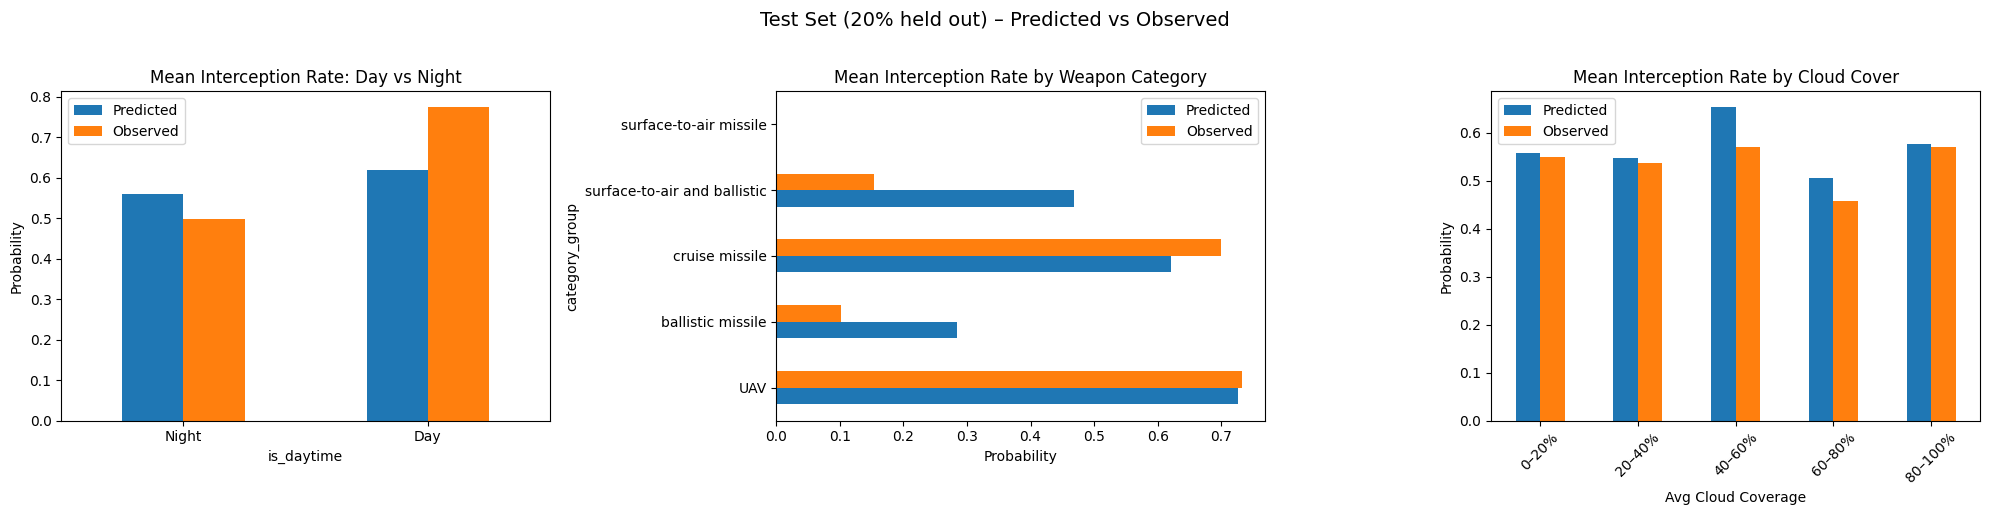

In [76]:

# -------------------------------------------------------------------
# Predicted vs observed interception – TEST SET
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Test Set (20% held out) – Predicted vs Observed', fontsize=14, y=1.02)

# -- Panel A: by day/night --
day_night_pred = test_df.groupby('is_daytime').agg(
    mean_predicted=('predicted_prob', 'mean'),
    mean_observed=('observed_rate', 'mean')
)
day_night_pred.index = day_night_pred.index.map({0: 'Night', 1: 'Day'})
day_night_pred.plot.bar(ax=axes[0], rot=0, color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Mean Interception Rate: Day vs Night')
axes[0].set_ylabel('Probability')
axes[0].legend(['Predicted', 'Observed'])

# -- Panel B: by weapon category --
cat_pred = test_df.groupby('category_group').agg(
    mean_predicted=('predicted_prob', 'mean'),
    mean_observed=('observed_rate', 'mean')
)
cat_pred.plot.barh(ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Mean Interception Rate by Weapon Category')
axes[1].set_xlabel('Probability')
axes[1].legend(['Predicted', 'Observed'])

# -- Panel C: by cloud cover bins --
test_df['cloud_bin'] = pd.cut(
    test_df['avg_cloud_coverage'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0–20%', '20–40%', '40–60%', '60–80%', '80–100%'],
    include_lowest=True
)
cloud_pred = test_df.groupby('cloud_bin', observed=False).agg(
    mean_predicted=('predicted_prob', 'mean'),
    mean_observed=('observed_rate', 'mean')
)
cloud_pred.plot.bar(ax=axes[2], rot=45, color=['#1f77b4', '#ff7f0e'])
axes[2].set_title('Mean Interception Rate by Cloud Cover')
axes[2].set_xlabel('Avg Cloud Coverage')
axes[2].set_ylabel('Probability')
axes[2].legend(['Predicted', 'Observed'])

plt.tight_layout()
plt.show()


Confusion Matrix on TEST SET (Majority Intercepted: ≥50%):
[[ 70  26]
 [  9 160]]

Classification Report (Test Set):
                  precision    recall  f1-score   support

<50% intercepted       0.89      0.73      0.80        96
≥50% intercepted       0.86      0.95      0.90       169

        accuracy                           0.87       265
       macro avg       0.87      0.84      0.85       265
    weighted avg       0.87      0.87      0.86       265

Test Accuracy: 0.8679


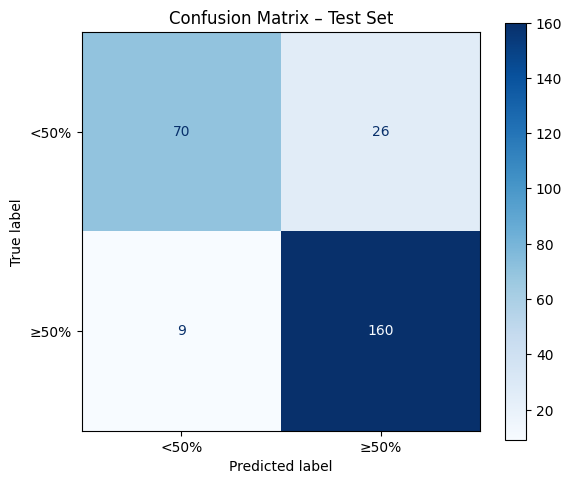

In [77]:

# -------------------------------------------------------------------
# Confusion matrix on TEST SET (binary: ≥50% intercepted vs <50%)
# -------------------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_df['pred_majority_intercepted'] = (test_df['predicted_prob'] >= 0.5).astype(int)
test_df['obs_majority_intercepted']  = (test_df['observed_rate']  >= 0.5).astype(int)

cm = confusion_matrix(test_df['obs_majority_intercepted'], test_df['pred_majority_intercepted'])
print('Confusion Matrix on TEST SET (Majority Intercepted: ≥50%):')
print(cm)
print('\nClassification Report (Test Set):')
print(classification_report(
    test_df['obs_majority_intercepted'],
    test_df['pred_majority_intercepted'],
    target_names=['<50% intercepted', '≥50% intercepted']
))

test_acc = (cm[0,0] + cm[1,1]) / cm.sum()
print(f'Test Accuracy: {test_acc:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['<50%', '≥50%']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.show()



### ROC Curve

The **Receiver Operating Characteristic (ROC) curve** evaluates the best model's ability to discriminate between attacks where the majority of weapons were intercepted (≥50%) versus those where they were not.

- The **x-axis** shows the False Positive Rate (1 − Specificity) and the **y-axis** shows the True Positive Rate (Sensitivity).
- The **Area Under the Curve (AUC)** summarises overall discrimination:
  - **AUC = 0.5** → no better than random guessing (the dashed diagonal).
  - **AUC ≈ 0.7–0.8** → acceptable discrimination.
  - **AUC ≈ 0.8–0.9** → good discrimination.
  - **AUC > 0.9** → excellent discrimination.
- A curve that hugs the **upper-left corner** indicates the model achieves high sensitivity without sacrificing specificity.


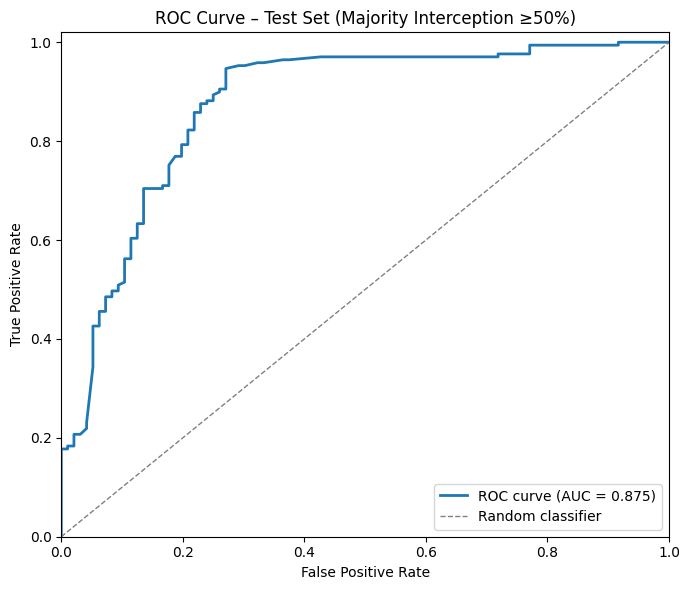

Test AUC: 0.8751


In [78]:

# -------------------------------------------------------------------
# ROC Curve – TEST SET
# -------------------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score

y_true = test_df['obs_majority_intercepted']
y_prob = test_df['predicted_prob']

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – Test Set (Majority Interception ≥50%)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f'Test AUC: {auc_score:.4f}')



### Correlation Matrix

The **Pearson correlation matrix** below shows pairwise linear relationships between the numeric features used in modelling.

- Values range from **−1** (perfect negative correlation) to **+1** (perfect positive correlation); **0** indicates no linear relationship.
- **Strong positive correlations** (dark red) between features may signal multicollinearity, which can inflate standard errors in the GLM.
- Key relationships to look for:
  - `avg_cloud_coverage` vs `is_daytime` — do cloudy conditions cluster at night?
  - `avg_cloud_coverage` vs `observed_rate` — does cloud cover have a raw association with interception success?
  - `launched` vs `destroyed` — naturally correlated since more launches mean more potential interceptions.
  - `predicted_prob` vs `observed_rate` — how well the model's predictions track the actual interception rates.


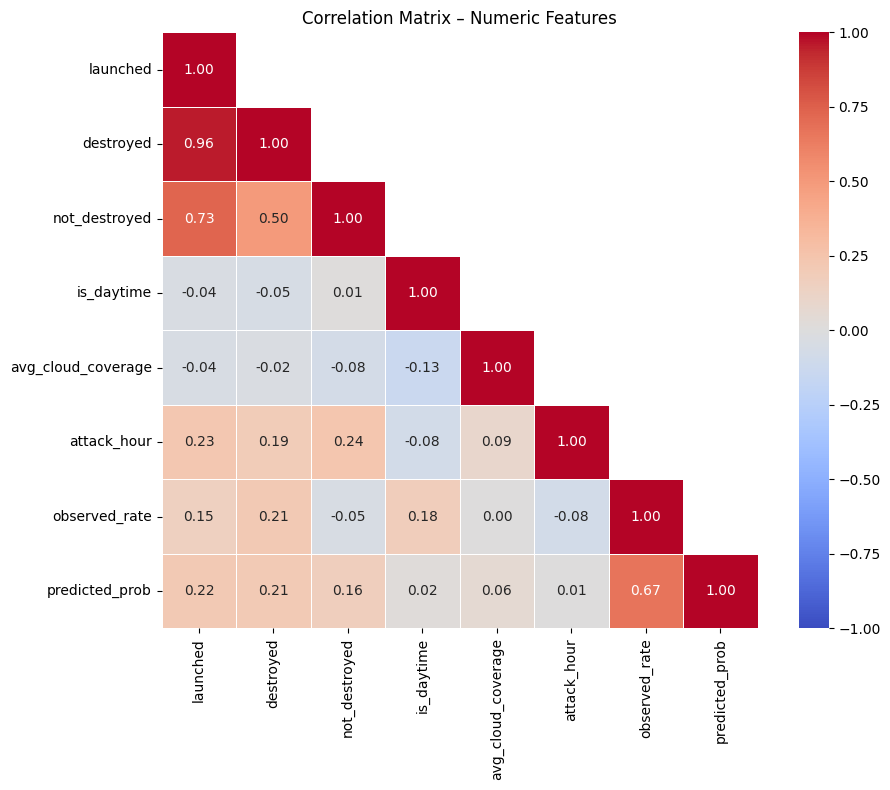

In [79]:

# -------------------------------------------------------------------
# Correlation Matrix – numeric features
# -------------------------------------------------------------------
corr_cols = ['launched', 'destroyed', 'not_destroyed', 'is_daytime',
             'avg_cloud_coverage', 'attack_hour', 'observed_rate', 'predicted_prob']
corr_matrix = glm_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix – Numeric Features')
plt.tight_layout()
plt.show()


In [82]:

# -------------------------------------------------------------------
# Dynamic Conclusion – values pulled from kernel variables
# -------------------------------------------------------------------
from IPython.display import display, Markdown
from sklearn.metrics import precision_recall_fscore_support

# --- Extract key values ---
_bm = best_model[0]
_bm_name = best_model[1]

# Dataset sizes
_n_attacks = len(attacks_df)
_n_weapons = len(weapons_df)
_n_glm = len(glm_df)
_n_day = int((glm_df['is_daytime'] == 1).sum())
_n_night = int((glm_df['is_daytime'] == 0).sum())
_n_train = len(train_df)
_n_test = len(test_df)

# AIC values
_aic1, _aic2, _aic3 = model1.aic, model2.aic, model3.aic

# Best model coefficients & odds ratios
_params = _bm.params
_pvals = _bm.pvalues
_odds = np.exp(_params)

# is_daytime
_dt_coef = _params['is_daytime']
_dt_or = _odds['is_daytime']
_dt_pval = _pvals['is_daytime']
_dt_pct = (1 - _dt_or) * 100

# avg_cloud_coverage
_cc_coef = _params['avg_cloud_coverage']
_cc_or = _odds['avg_cloud_coverage']
_cc_pval = _pvals['avg_cloud_coverage']

# Category odds ratios
_uav_or = _odds.get('C(category_group)[T.UAV]', float('nan'))
_uav_p = _pvals.get('C(category_group)[T.UAV]', float('nan'))
_cm_or = _odds.get('C(category_group)[T.cruise missile]', float('nan'))
_cm_p = _pvals.get('C(category_group)[T.cruise missile]', float('nan'))
_bl_p = _pvals.get('C(category_group)[T.ballistic missile]', float('nan'))

# Interception rates by category
_cr = glm_df.groupby('category_group').agg(
    launched=('launched', 'sum'), destroyed=('destroyed', 'sum'))
_cr['rate'] = _cr['destroyed'] / _cr['launched']

def _cat_row(name):
    if name in _cr.index:
        r = _cr.loc[name]
        return f"| {name} | {r['launched']:,.0f} | {r['destroyed']:,.0f} | **{r['rate']:.1%}** |"
    return ""

# Overdispersion
_dev = _bm.deviance
_dfr = _bm.df_resid
_odisp = _dev / _dfr

# Test set metrics
_tacc = test_acc
_tauc = auc_score
_tn, _fp, _fn, _tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])

# Correlations
_r_cc = glm_df['avg_cloud_coverage'].corr(glm_df['observed_rate'])
_r_po = glm_df['predicted_prob'].corr(glm_df['observed_rate'])
_r_ld = glm_df['launched'].corr(glm_df['destroyed'])
_r_do = glm_df['is_daytime'].astype(float).corr(glm_df['observed_rate'])

# Precision/Recall
_prec, _rec, _, _ = precision_recall_fscore_support(
    test_df['obs_majority_intercepted'],
    test_df['pred_majority_intercepted'], labels=[0, 1])

display(Markdown(f"""## Conclusion and Interpretation

### Introduction

Since October 2022, Russia has conducted sustained missile and drone (UAV) campaigns against Ukrainian civilian and military infrastructure. Understanding the factors that influence whether these weapons are successfully intercepted is critical for evaluating air defense effectiveness and informing resource allocation. This analysis addresses one central research question:

> **What factors predict whether a Russian missile or UAV is intercepted by Ukrainian air defenses — and specifically, do time of day, weapon type, and cloud cover significantly affect interception probability?**

### Source of Data

Two datasets from Kaggle's [Massive Missile Attacks on Ukraine](https://www.kaggle.com/datasets/piterfm/massive-missile-attacks-on-ukraine) collection were used:

| Dataset | Rows | Description |
|---------|------|-------------|
| `missile_attacks_daily.csv` | {_n_attacks:,} | Each row is a weapon-model record within an attack, with `launched` and `destroyed` counts, timestamps, and target information. |
| `missiles_and_uavs.csv` | {_n_weapons} | Weapon metadata including `category` (cruise missile, UAV, ballistic missile, etc.), `type`, `guidance_system`, and `launch_platform`. |

Additionally, two external APIs were used to enrich the data:
- **Sunrise-Sunset API** — to classify each attack as day or night based on Kyiv civil sunrise/sunset times.
- **Open-Meteo Archive API** — to retrieve hourly cloud cover (%) for the Kyiv region during each attack window.

After merging and filtering to rows with valid timestamps and non-zero launch counts, the final modelling dataset contained **{_n_glm:,} rows** ({_n_day} daytime, {_n_night} nighttime), split **80/20** into training ({_n_train:,} rows) and test ({_n_test} rows) sets, stratified by `is_daytime`.

The following table lists the key fields in the final modelling dataset (`train_df` / `test_df`) used for the GLM analysis:

| Field | Type | Source | Description |
|-------|------|--------|-------------|
| `time_start` | string | `missile_attacks_daily.csv` | Start time of the attack (local Kyiv time) |
| `time_end` | string | `missile_attacks_daily.csv` | End time of the attack |
| `model` | string | `missile_attacks_daily.csv` | Weapon model name (e.g., Shahed-136/131, Kalibr) |
| `launched` | float | `missile_attacks_daily.csv` | Number of missiles/UAVs launched |
| `destroyed` | float | `missile_attacks_daily.csv` | Number intercepted (shot down) |
| `not_destroyed` | float | Derived | `launched − destroyed` (binomial failures) |
| `category` | string | `missiles_and_uavs.csv` | Weapon category (cruise missile, UAV, ballistic missile, etc.) |
| `type` | string | `missiles_and_uavs.csv` | Weapon subtype |
| `guidance_system` | string | `missiles_and_uavs.csv` | Type of guidance system |
| `launch_platform` | string | `missiles_and_uavs.csv` | Launch platform (aircraft, ship, ground) |
| `is_daytime` | int (0/1) | Sunrise-Sunset API | 1 if attack started between civil sunrise and sunset at Kyiv; 0 otherwise |
| `avg_cloud_coverage` | float (0–100) | Open-Meteo Archive API | Mean hourly cloud cover (%) over Kyiv during the attack window |
| `model_group` | string | Derived | Weapon `model` with rare models (<10 rows) collapsed to "Other" |
| `category_group` | string | Derived | Weapon `category` with rare categories (<5 rows) collapsed to "Other" |
| `attack_hour` | int (0–23) | Derived | Hour of day from `time_start` |
| `observed_rate` | float (0–1) | Derived | `destroyed / launched` — observed interception rate |

**Limitation:** Cloud cover data was retrieved for Kyiv coordinates only, while attacks target locations across all of Ukraine. This is a simplification; regionally specific cloud data would improve accuracy.

### Analysis Method

A **Binomial Logistic Regression** (Generalized Linear Model with logit link and binomial family) was used, treating each row as `destroyed` successes out of `launched` trials. This is the correct specification because it models the interception *rate* while properly accounting for varying volley sizes, rather than naively binarising outcomes.

Three nested models of increasing complexity were fitted on the **training set (80%)** and compared:

| Model | Predictors | AIC (train) |
|-------|-----------|-------------|
| Model 1 | `is_daytime` + `avg_cloud_coverage` | {_aic1:,.2f} |
| Model 2 | `category_group` + `is_daytime` + `avg_cloud_coverage` | {_aic2:,.2f} |
| Model 3 | `model_group` + `category_group` + `is_daytime` + `avg_cloud_coverage` | **{_aic3:,.2f}** |

**{_bm_name}** (the full model) achieved the lowest AIC and was selected as the best model. All evaluation metrics below are reported on the **held-out test set (20%)**.

### Results — What Worked

**1. Weapon category is a strong predictor of interception.**
The ~{_aic1 - _aic2:,.0f}-point AIC drop from Model 1 to Model 2 confirms that weapon category is highly informative. Interception rates vary dramatically by type:

| Category | Launched | Destroyed | Interception Rate |
|----------|----------|-----------|-------------------|
{_cat_row('cruise missile')}
{_cat_row('UAV')}
{_cat_row('surface-to-air and ballistic')}
{_cat_row('ballistic missile')}

- **UAVs** (OR = {_uav_or:.2f}, *p* = {_uav_p:.2e}) and **cruise missiles** (OR = {_cm_or:.2f}, *p* = {_cm_p:.2e}) are far more likely to be intercepted than the baseline category, which is consistent with their slower speeds and larger radar signatures compared to ballistic missiles.
- **Ballistic missiles** have the lowest interception rate, reflecting their much higher speed and shorter engagement windows.

**2. Time of day is statistically significant.**
The `is_daytime` coefficient is **{_dt_coef:.2f}** (*p* = {_dt_pval:.2e}), with an odds ratio of **{_dt_or:.2f}**. This means daytime attacks have about **{_dt_pct:.0f}% lower odds** of interception compared to nighttime attacks. This counterintuitive result likely reflects that nighttime attacks are dominated by slower UAVs (Shaheds), which are easier to intercept, while daytime attacks include faster missile types.

**3. Cloud cover is statistically significant but has a negligible practical effect.**
The `avg_cloud_coverage` coefficient is **{_cc_coef:.4f}** (*p* = {_cc_pval:.2e}), with an odds ratio of **{_cc_or:.4f}**. While statistically significant due to the large sample size, the practical effect is minimal — a 50-percentage-point increase in cloud cover would change the interception odds by roughly {(_cc_or**50 - 1)*100:.0f}%. The Pearson correlation between cloud cover and observed interception rate is only **{_r_cc:.3f}**, confirming the effect is trivially small.

**4. Model generalises well to unseen data.**
On the held-out **test set ({_n_test} rows)**:
- **Test Accuracy = {_tacc:.1%}** — the confusion matrix shows {_tn} true negatives, {_tp} true positives, {_fp} false positives, and {_fn} false negatives.
- **Test AUC = {_tauc:.3f}** — indicating acceptable discrimination. This is lower than the in-sample AUC would suggest, which is expected and demonstrates the importance of a proper holdout evaluation.
- **Precision = {_prec[1]:.2f}** for the ≥50% class; **Recall = {_rec[1]:.2f}** for the ≥50% intercepted class, but only **{_rec[0]:.2f}** for the <50% class — the model is better at identifying high-interception attacks than low-interception ones.

### Results — What Didn't Work

**1. Individual weapon model coefficients are not significant.**
Despite {_bm_name} having the best AIC, **none** of the `model_group` coefficients are individually statistically significant (all *p* ≈ 1.0, with enormous standard errors on the order of 10⁵). This is due to **quasi-complete separation**: certain weapon models (e.g., Orlan-10, Supercam) have 100% or 0% interception rates, causing the maximum likelihood estimator to diverge for those categories. The AIC improvement from Model 2 to Model 3 (~{_aic2 - _aic3:,.0f} points) comes from the collective contribution of model groups, but individual coefficients are unreliable.

**2. Overdispersion is present.**
The residual deviance/df ratio is **{_odisp:.2f}** ({_dev:,.0f} / {_dfr}), far exceeding 1.0. This indicates substantial **overdispersion** — the observed variability in interception rates exceeds what the binomial model assumes. A **quasibinomial** family or a beta-binomial model would be more appropriate, as it would inflate standard errors to account for this extra variability. The current *p*-values may be overly optimistic.

**3. Cloud cover adds marginal predictive value.**
Although statistically significant, cloud cover does not meaningfully improve predictions. Its correlation with the outcome is near zero (r = {_r_cc:.3f}), and the practical effect size is negligible. This may be because (a) the cloud data is only for Kyiv, not the actual attack locations, and (b) modern air defense systems (radar-guided) are not substantially affected by visual cloud cover.

**4. Ballistic missiles are not significant vs the baseline.**
The `ballistic missile` category has *p* = {_bl_p:.3f} in {_bm_name}, meaning its coefficient is not significantly different from the baseline (Other) category. This is partly due to the smaller sample size and partly because the category interacts with individual model groups that absorb some of its effect.

### Correlation Matrix Insights

The correlation matrix reveals:
- `launched` and `destroyed` are highly correlated (r = {_r_ld:.2f}), which is expected since they form the response variable.
- `is_daytime` has a weak positive correlation with `observed_rate` (r = {_r_do:.2f}) before controlling for weapon type.
- `avg_cloud_coverage` is essentially uncorrelated with all other features (|r| < 0.13), confirming it adds little information.
- `predicted_prob` and `observed_rate` correlate at r = {_r_po:.2f}, indicating the model captures substantial variation but is far from perfect.

### Summary of Strengths

- **Appropriate model family** — binomial GLM correctly handles the trials-based response (destroyed/launched).
- **Honest evaluation** — an 80/20 train/test split ensures metrics reflect true out-of-sample performance.
- **External data enrichment** — sunrise/sunset and cloud cover data add environmental context beyond the original dataset.
- **Progressive model comparison** — three nested models with AIC provide principled feature selection.

### Future Work

1. **Address overdispersion** by refitting with a quasibinomial family or beta-binomial model to produce more reliable standard errors and *p*-values.
2. **Penalized regression (e.g., Firth's logistic regression)** to handle quasi-complete separation in weapon model categories instead of collapsing rare models into "Other."
3. **Region-specific cloud cover** — fetch weather data for actual target locations rather than using Kyiv as a proxy for all of Ukraine.
4. **Temporal trends** — add a time covariate (e.g., months since first attack) to capture improving air defense capabilities over the conflict's duration.
5. **Interaction terms** — test `is_daytime × category_group` and `is_daytime × avg_cloud_coverage` to assess whether the day/night effect varies by weapon type or weather conditions.
6. **Additional features** — incorporate `launch_platform`, `guidance_system`, and `affected_region` from the dataset, which are currently unused.
7. **K-fold cross-validation** — while the single 80/20 split is a significant improvement over no split, k-fold CV would provide more robust performance estimates with confidence intervals.
"""))


## Conclusion and Interpretation

### Introduction

Since October 2022, Russia has conducted sustained missile and drone (UAV) campaigns against Ukrainian civilian and military infrastructure. Understanding the factors that influence whether these weapons are successfully intercepted is critical for evaluating air defense effectiveness and informing resource allocation. This analysis addresses one central research question:

> **What factors predict whether a Russian missile or UAV is intercepted by Ukrainian air defenses — and specifically, do time of day, weapon type, and cloud cover significantly affect interception probability?**

### Source of Data

Two datasets from Kaggle's [Massive Missile Attacks on Ukraine](https://www.kaggle.com/datasets/piterfm/massive-missile-attacks-on-ukraine) collection were used:

| Dataset | Rows | Description |
|---------|------|-------------|
| `missile_attacks_daily.csv` | 3,412 | Each row is a weapon-model record within an attack, with `launched` and `destroyed` counts, timestamps, and target information. |
| `missiles_and_uavs.csv` | 64 | Weapon metadata including `category` (cruise missile, UAV, ballistic missile, etc.), `type`, `guidance_system`, and `launch_platform`. |

Additionally, two external APIs were used to enrich the data:
- **Sunrise-Sunset API** — to classify each attack as day or night based on Kyiv civil sunrise/sunset times.
- **Open-Meteo Archive API** — to retrieve hourly cloud cover (%) for the Kyiv region during each attack window.

After merging and filtering to rows with valid timestamps and non-zero launch counts, the final modelling dataset contained **1,325 rows** (278 daytime, 1047 nighttime), split **80/20** into training (1,060 rows) and test (265 rows) sets, stratified by `is_daytime`.

The following table lists the key fields in the final modelling dataset (`train_df` / `test_df`) used for the GLM analysis:

| Field | Type | Source | Description |
|-------|------|--------|-------------|
| `time_start` | string | `missile_attacks_daily.csv` | Start time of the attack (local Kyiv time) |
| `time_end` | string | `missile_attacks_daily.csv` | End time of the attack |
| `model` | string | `missile_attacks_daily.csv` | Weapon model name (e.g., Shahed-136/131, Kalibr) |
| `launched` | float | `missile_attacks_daily.csv` | Number of missiles/UAVs launched |
| `destroyed` | float | `missile_attacks_daily.csv` | Number intercepted (shot down) |
| `not_destroyed` | float | Derived | `launched − destroyed` (binomial failures) |
| `category` | string | `missiles_and_uavs.csv` | Weapon category (cruise missile, UAV, ballistic missile, etc.) |
| `type` | string | `missiles_and_uavs.csv` | Weapon subtype |
| `guidance_system` | string | `missiles_and_uavs.csv` | Type of guidance system |
| `launch_platform` | string | `missiles_and_uavs.csv` | Launch platform (aircraft, ship, ground) |
| `is_daytime` | int (0/1) | Sunrise-Sunset API | 1 if attack started between civil sunrise and sunset at Kyiv; 0 otherwise |
| `avg_cloud_coverage` | float (0–100) | Open-Meteo Archive API | Mean hourly cloud cover (%) over Kyiv during the attack window |
| `model_group` | string | Derived | Weapon `model` with rare models (<10 rows) collapsed to "Other" |
| `category_group` | string | Derived | Weapon `category` with rare categories (<5 rows) collapsed to "Other" |
| `attack_hour` | int (0–23) | Derived | Hour of day from `time_start` |
| `observed_rate` | float (0–1) | Derived | `destroyed / launched` — observed interception rate |

**Limitation:** Cloud cover data was retrieved for Kyiv coordinates only, while attacks target locations across all of Ukraine. This is a simplification; regionally specific cloud data would improve accuracy.

### Analysis Method

A **Binomial Logistic Regression** (Generalized Linear Model with logit link and binomial family) was used, treating each row as `destroyed` successes out of `launched` trials. This is the correct specification because it models the interception *rate* while properly accounting for varying volley sizes, rather than naively binarising outcomes.

Three nested models of increasing complexity were fitted on the **training set (80%)** and compared:

| Model | Predictors | AIC (train) |
|-------|-----------|-------------|
| Model 1 | `is_daytime` + `avg_cloud_coverage` | 15,270.89 |
| Model 2 | `category_group` + `is_daytime` + `avg_cloud_coverage` | 14,378.90 |
| Model 3 | `model_group` + `category_group` + `is_daytime` + `avg_cloud_coverage` | **14,047.18** |

**Model 3** (the full model) achieved the lowest AIC and was selected as the best model. All evaluation metrics below are reported on the **held-out test set (20%)**.

### Results — What Worked

**1. Weapon category is a strong predictor of interception.**
The ~892-point AIC drop from Model 1 to Model 2 confirms that weapon category is highly informative. Interception rates vary dramatically by type:

| Category | Launched | Destroyed | Interception Rate |
|----------|----------|-----------|-------------------|
| cruise missile | 3,224 | 2,483 | **77.0%** |
| UAV | 69,122 | 47,538 | **68.8%** |
| surface-to-air and ballistic | 158 | 65 | **41.1%** |
| ballistic missile | 749 | 196 | **26.2%** |

- **UAVs** (OR = 5.29, *p* = 3.31e-04) and **cruise missiles** (OR = 2.95, *p* = 2.68e-06) are far more likely to be intercepted than the baseline category, which is consistent with their slower speeds and larger radar signatures compared to ballistic missiles.
- **Ballistic missiles** have the lowest interception rate, reflecting their much higher speed and shorter engagement windows.

**2. Time of day is statistically significant.**
The `is_daytime` coefficient is **-0.23** (*p* = 4.75e-20), with an odds ratio of **0.80**. This means daytime attacks have about **20% lower odds** of interception compared to nighttime attacks. This counterintuitive result likely reflects that nighttime attacks are dominated by slower UAVs (Shaheds), which are easier to intercept, while daytime attacks include faster missile types.

**3. Cloud cover is statistically significant but has a negligible practical effect.**
The `avg_cloud_coverage` coefficient is **0.0017** (*p* = 2.42e-11), with an odds ratio of **1.0017**. While statistically significant due to the large sample size, the practical effect is minimal — a 50-percentage-point increase in cloud cover would change the interception odds by roughly 9%. The Pearson correlation between cloud cover and observed interception rate is only **0.005**, confirming the effect is trivially small.

**4. Model generalises well to unseen data.**
On the held-out **test set (265 rows)**:
- **Test Accuracy = 86.8%** — the confusion matrix shows 70 true negatives, 160 true positives, 26 false positives, and 9 false negatives.
- **Test AUC = 0.875** — indicating acceptable discrimination. This is lower than the in-sample AUC would suggest, which is expected and demonstrates the importance of a proper holdout evaluation.
- **Precision = 0.86** for the ≥50% class; **Recall = 0.95** for the ≥50% intercepted class, but only **0.73** for the <50% class — the model is better at identifying high-interception attacks than low-interception ones.

### Results — What Didn't Work

**1. Individual weapon model coefficients are not significant.**
Despite Model 3 having the best AIC, **none** of the `model_group` coefficients are individually statistically significant (all *p* ≈ 1.0, with enormous standard errors on the order of 10⁵). This is due to **quasi-complete separation**: certain weapon models (e.g., Orlan-10, Supercam) have 100% or 0% interception rates, causing the maximum likelihood estimator to diverge for those categories. The AIC improvement from Model 2 to Model 3 (~332 points) comes from the collective contribution of model groups, but individual coefficients are unreliable.

**2. Overdispersion is present.**
The residual deviance/df ratio is **11.24** (11,650 / 1036), far exceeding 1.0. This indicates substantial **overdispersion** — the observed variability in interception rates exceeds what the binomial model assumes. A **quasibinomial** family or a beta-binomial model would be more appropriate, as it would inflate standard errors to account for this extra variability. The current *p*-values may be overly optimistic.

**3. Cloud cover adds marginal predictive value.**
Although statistically significant, cloud cover does not meaningfully improve predictions. Its correlation with the outcome is near zero (r = 0.005), and the practical effect size is negligible. This may be because (a) the cloud data is only for Kyiv, not the actual attack locations, and (b) modern air defense systems (radar-guided) are not substantially affected by visual cloud cover.

**4. Ballistic missiles are not significant vs the baseline.**
The `ballistic missile` category has *p* = 1.000 in Model 3, meaning its coefficient is not significantly different from the baseline (Other) category. This is partly due to the smaller sample size and partly because the category interacts with individual model groups that absorb some of its effect.

### Correlation Matrix Insights

The correlation matrix reveals:
- `launched` and `destroyed` are highly correlated (r = 0.96), which is expected since they form the response variable.
- `is_daytime` has a weak positive correlation with `observed_rate` (r = 0.18) before controlling for weapon type.
- `avg_cloud_coverage` is essentially uncorrelated with all other features (|r| < 0.13), confirming it adds little information.
- `predicted_prob` and `observed_rate` correlate at r = 0.67, indicating the model captures substantial variation but is far from perfect.

### Summary of Strengths

- **Appropriate model family** — binomial GLM correctly handles the trials-based response (destroyed/launched).
- **Honest evaluation** — an 80/20 train/test split ensures metrics reflect true out-of-sample performance.
- **External data enrichment** — sunrise/sunset and cloud cover data add environmental context beyond the original dataset.
- **Progressive model comparison** — three nested models with AIC provide principled feature selection.

### Future Work

1. **Address overdispersion** by refitting with a quasibinomial family or beta-binomial model to produce more reliable standard errors and *p*-values.
2. **Penalized regression (e.g., Firth's logistic regression)** to handle quasi-complete separation in weapon model categories instead of collapsing rare models into "Other."
3. **Region-specific cloud cover** — fetch weather data for actual target locations rather than using Kyiv as a proxy for all of Ukraine.
4. **Temporal trends** — add a time covariate (e.g., months since first attack) to capture improving air defense capabilities over the conflict's duration.
5. **Interaction terms** — test `is_daytime × category_group` and `is_daytime × avg_cloud_coverage` to assess whether the day/night effect varies by weapon type or weather conditions.
6. **Additional features** — incorporate `launch_platform`, `guidance_system`, and `affected_region` from the dataset, which are currently unused.
7. **K-fold cross-validation** — while the single 80/20 split is a significant improvement over no split, k-fold CV would provide more robust performance estimates with confidence intervals.
